Moments play crucial role in analysis, usually we need them to estimate different parameters of data and find confidence intervals.

$$ Let's\:show\:that\:\mu_k=\frac{1}{n}\sum_{i=1}^{n}(x_i-\overline{x}_n)^k\:is\:unbiased\:and\:consistent $$
$$ \frac{1}{n}\sum_{i=1}^{n}(x_i-\overline{x}_n)^k=\frac{1}{n}\sum_{i=1}^{n}((x_i-\mu) - (\overline{x}_n - \mu))^k $$
Using binomial theorem

$$ \frac{1}{n}\sum_{i=1}^{n}\sum_{j=0}^{k}\mathrm{C}_{k}^{j}(x_i-\mu)^j(-1)^{k-j}\cdot(\overline{x}_n-\mu)^{k-j} $$
$$ (\overline{x}_n-\mu)^{k-j}\approx0\:because\:\overline{x}_n\xrightarrow{P}\mu, \:\:0^{k-j}>0\:iff\:k = j $$
$$ Expression \:converges\:to\:\mu_k\:for\:k=j\:otherwise\:0 $$

In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math
import scipy.stats as stats

In [2]:
random.seed(42)
np.random.seed(42)
sample = np.random.uniform(2, 4, size=(900, 1000))

$$ \widehat{\mu}_2 \sim N(\mu_2, \frac{\mu_4-\sigma^4}{n}) $$

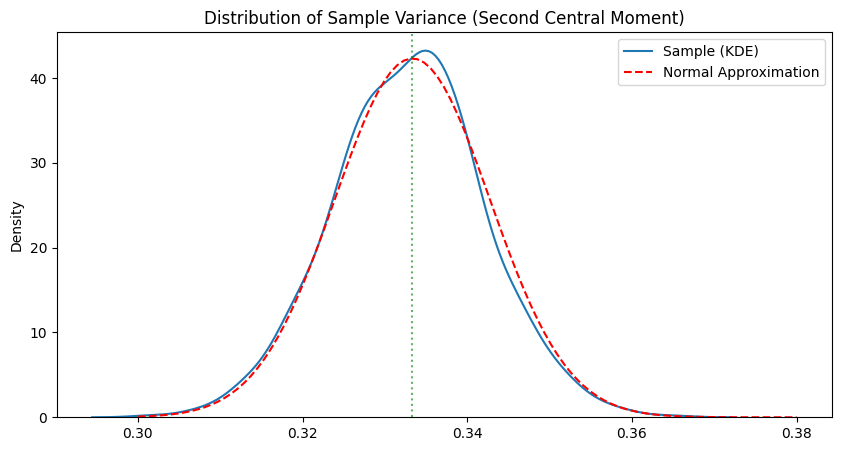

In [3]:
moments = np.var(sample, axis=1)

mu_2_true = 1/3
mu_4_true = 0.2

se_true = np.sqrt((mu_4_true - mu_2_true**2) / len(sample[1]))
x_values = np.linspace(0.3, 0.38, 100)
y_values = stats.norm.pdf(x_values, loc=mu_2_true, scale=se_true)

plt.figure(figsize=(10, 5))
plt.title("Distribution of Sample Variance (Second Central Moment)")
sns.kdeplot(moments, label="Sample (KDE)")
plt.plot(x_values, y_values, label="Normal Approximation", color='red', linestyle='--')
plt.axvline(mu_2_true, color='green', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

$$Let's\:derive\:the\:asymptotical\:distribution\:for\:s^2$$
$$ \widehat{\sigma}^2=\frac{n-1}{n}\cdot s^2=\frac{1}{n}\sum_{i=1}^{n}[(x_i-\mu)-(\overline{x}_n-\mu)]^2=\mu_2 -\frac{2}{n}\sum_{i=1}^{n}(x_i-\mu)(\overline{x}_n-\mu)=\frac{2\cdot{(\overline{x}_n-\mu)}}{n}\sum_{i=1}^{n}(x_i-\mu)=-2(\overline{x}_n-\mu)=\widehat{\mu}_2-(\overline{x}_n-\mu)^2$$
$$ \sqrt{n}(s^2_n-\sigma^2)\sim ? $$
$$ \frac{n-1}{n}s_n^2-\frac{n-1}{n}\sigma^2=\widehat{\mu}_2-(\overline{x}_n-\mu)^2-\frac{n-1}{n}\sigma^2
\:(multiply\: everything\: by\: \sqrt{n}\cdot\frac{n}{n-1}) $$
$$ \sqrt{n}(s_n^2-\sigma^2_n)=\frac{n}{n-1}\cdot\sqrt{n}\cdot\mu_2-\sqrt{n}\cdot\mu_2-\sqrt{n}\cdot\frac{n}{n-1}(\overline{x}_n-\mu)^2 \:|\:(\lim_{n \to \infty } \frac{n}{n-1}\to 1) $$
$$ \sqrt{n}(s_n^2-\sigma^2_n)\sim \sqrt{n}(\widehat{\mu}_2-\mu_2)\sim N(0, \mu_4-\sigma^4) $$
$$ s^2_n\sim N(\sigma^2,\frac{\mu_4-\sigma^4}{n}) $$


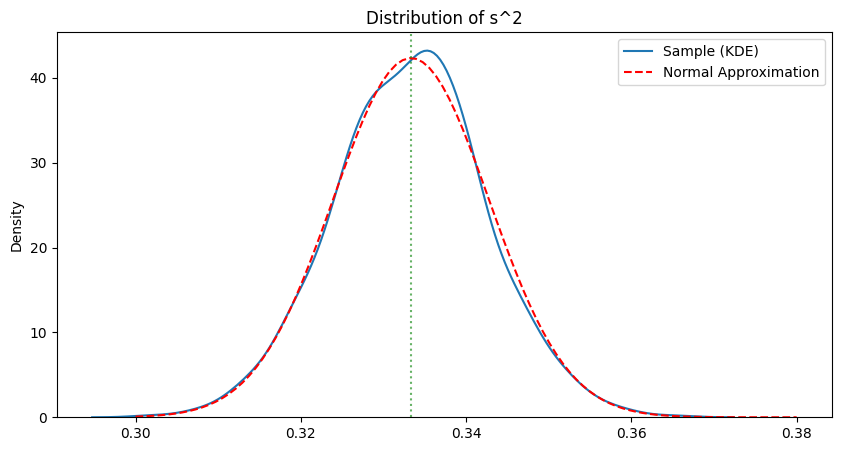

In [4]:
moments = np.var(sample, axis=1, ddof=1)

mu_2_true = 1/3
mu_4_true = 0.2

se_true = np.sqrt((mu_4_true - mu_2_true**2) / len(sample[1]))
x_values = np.linspace(0.3, 0.38, 100)
y_values = stats.norm.pdf(x_values, loc=mu_2_true, scale=se_true)

plt.figure(figsize=(10, 5))
plt.title("Distribution of s^2")
sns.kdeplot(moments, label="Sample (KDE)")
plt.plot(x_values, y_values, label="Normal Approximation", color='red', linestyle='--')
plt.axvline(mu_2_true, color='green', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Correction to width is poor, but correction to centering is useful because of small scale

$$More\:precise\:estimation:s^2_n\sim N(\sigma^2,\frac{1}{n}(\mu_4-\frac{n-3}{n-1}\sigma^4))$$

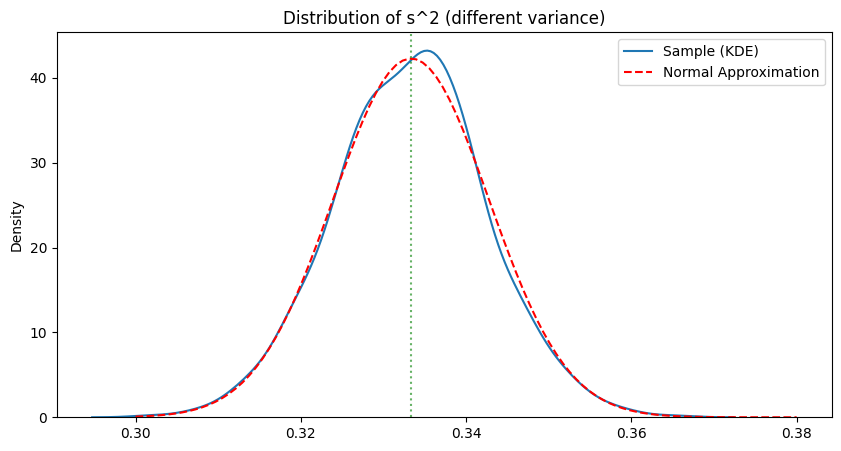

In [5]:
moments = np.var(sample, axis=1, ddof=1)

mu_2_true = 1/3
mu_4_true = 0.2
n = len(sample[1])

se_true = np.sqrt((mu_4_true - ((n - 3) / (n - 1) * mu_2_true**2)) / n)
x_values = np.linspace(0.3, 0.38, 100)
y_values = stats.norm.pdf(x_values, loc=mu_2_true, scale=se_true)

plt.figure(figsize=(10, 5))
plt.title("Distribution of s^2 (different variance)")
sns.kdeplot(moments, label="Sample (KDE)")
plt.plot(x_values, y_values, label="Normal Approximation", color='red', linestyle='--')
plt.axvline(mu_2_true, color='green', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

For large n difference between above estimators is difficult to notice

$$ Estimator\:\ \widehat{\theta}\: is\:unbiased\:if\:E(\widehat{\theta})=\theta_0\:and\:consistent\:if\:
\widehat{\theta}\xrightarrow{P}\theta_0 $$

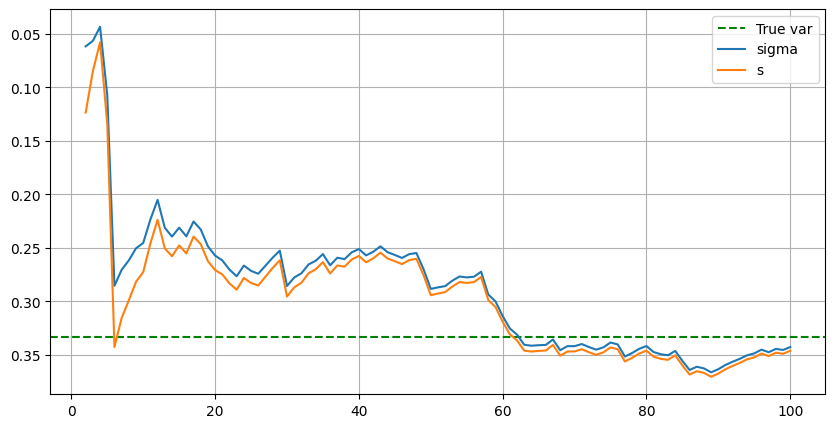

In [6]:
n = 100
sample_1d = np.random.uniform(2, 4, n)
sigma = []
s = []
true_var = 1/3

for i in range(1, n):
    s.append(sample_1d[:i+1].var())
    s.append(sample_1d[:i+1].var(ddof=1))

x_values = np.linspace(2, n, n - 1)

plt.figure(figsize=(10, 5))
plt.axhline(mu_2_true, color='green', label=f'True var', linestyle='--')
plt.plot(x_values, s[0::2], label="sigma")
plt.plot(x_values, s[1::2], label="s")
plt.grid(True)
plt.gca().invert_yaxis()
plt.legend()


It's difficult to say which estimator is better in this case. In order to do that we need to introduce "Efficiency". Estimator a is better than estimator b if MSE(a) < MSE(b). Where MSE - mean squared error. Best estimator doesn't exist, but conditions influence the effectiveness of the estimators. 

Note: This is also called bias variance tradeoff, s^2 has smaller bias and sigma^2 has smaller variance.

We will use bootstrap to calculate MSE and see which estimation is more effective

In [7]:
n_iterations = 5000
boot_samples = np.random.choice(sample_1d, size=(n_iterations, 60), replace=True)
boot_s = np.var(boot_samples, axis=1, ddof=1)
boot_var = np.var(boot_samples, axis=1)

est_s = np.var(sample_1d, ddof=1)

mse_s = np.mean((boot_s - est_s)**2)
mse_sigma = np.mean((boot_var - est_s)**2)

print(f"MSE for s: {mse_s}", "\n", f"MSE for sigma: {mse_sigma}", sep="")

MSE for s: 0.0018642899815655902
MSE for sigma: 0.0018876062559241163


$$ For\:this\:case\: s \: is \: more \: effective \: estimation \: than \: \sigma \: even \: if\:it\:lies\:furhter\:from\:actual\:variance $$

We can also estimate the asymptotical distribution of quantiles
$$ \widehat{q}_\alpha\sim N(q_\alpha, \frac{\alpha(1-\alpha)}{n\cdot f(q_\alpha)^2}) $$

For median (alpha = 0.5) distribution will be:

$$ \widehat{med}\sim N(med, \frac{1}{4\cdot n\cdot f(med)^2}) $$

One of the ways to estimate f at some is to use gaussian approximation of distrubtion (gaussian_kde from scipy.stats)

In [8]:
from scipy.stats import gaussian_kde

n = 10000
d_lambda = 2
sample_exp = np.random.exponential(scale=1/d_lambda, size=n)
alpha = 0.25 #Quantile

sample_exp_sorted = sorted(sample_exp)
q_est = sample_exp_sorted[int(n * alpha) - 1]
density = gaussian_kde(sample_exp)

q_var = alpha * (1 - alpha) / (n * (density(q_est) ** 2))

print(q_est, q_var[0])

0.14481683037784415 8.962246626982832e-06


$$ Theoretical\:mean\:and\:variance\:for\:exponential\:distribution $$
$$ f_X(x) = \lambda e^{-\lambda x} \: (for\:x>0) \: and \: F_X(x) = (1-e^{-\lambda x}) $$
$$ Quantile: \:1-e^{-\lambda x_p}=p \: \to \:e^{-\lambda x_p}=1-p \: \to \:-\lambda x_p=ln(1-p) $$
$$ x_p=\frac{-ln(1-p)}{\lambda} $$
$$ Variance: \: Var(\widehat{x}_p)=\frac{p(1-p)}{n\cdot f(x_p)^2} $$
$$ f(x_p)=\lambda e^{-\lambda\frac{-ln(1-p)}{\lambda}} = \lambda(1-p) $$
$$ Var(\widehat{x}_p)=\frac{p}{n\lambda^2(1-p)} $$

Now we can construct theoretical distribution and compare it with approximation

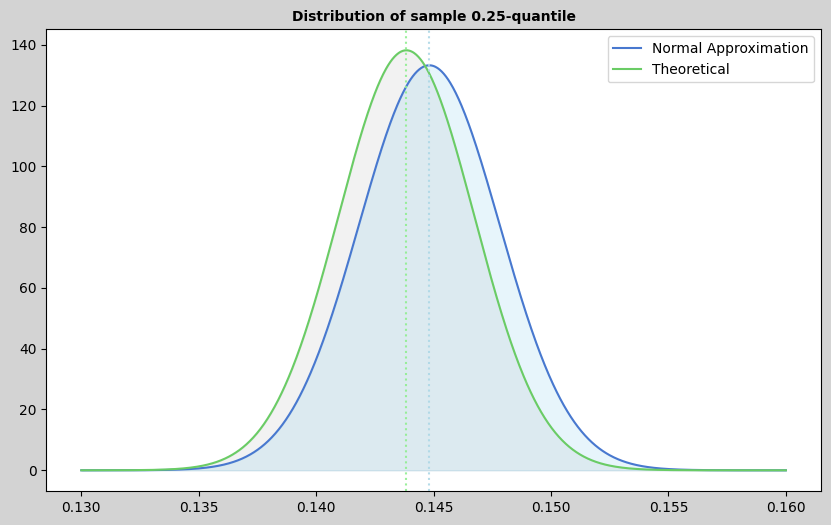

In [ ]:
t_mean = -np.log(1 - alpha) / d_lambda # alpha = p
t_var = alpha / (n * d_lambda ** 2 * (1 - alpha))

x_values = np.linspace(0.13, 0.16, 1000)
t_values = sc.stats.norm.pdf(x_values, loc=t_mean, scale=np.sqrt(t_var) )
y_values = sc.stats.norm.pdf(x_values, loc=q_est, scale=np.sqrt(q_var[0]) )

plt.style.use('seaborn-v0_8-muted') 

plt.figure(figsize=(10, 6), dpi=100, facecolor="lightgray")

"""
boot_sample_exp = np.random.exponential(scale=1/d_lambda, size=2 * n)
n_iterations = 1000
boot_n = 10000
idx = int(n * alpha)
boot_samples_exp = np.random.choice(sample_exp, size=(n_iterations, boot_n), replace=True)

quant = np.partition(boot_samples_exp, idx, axis=1)

My laptop can't run this part :(
"""


plt.plot(x_values, y_values, label="Normal Approximation")
plt.fill_between(x_values, t_values, color='grey', alpha=0.1)
plt.plot(x_values, t_values, label="Theoretical")
plt.fill_between(x_values, y_values, color='skyblue', alpha=0.2)

plt.axvline(t_mean, color='lightgreen', linestyle=':', alpha=0.9)
plt.axvline(q_est, color='lightblue', linestyle=':', alpha=0.9)
plt.title(f"Distribution of sample {alpha}-quantile", fontweight='bold', fontsize=10)
plt.legend()